# Lab 04: Eigendecomposition

**Reference:** Goodfellow et al. *Deep Learning*, Chapter 2, Section 2.7

Eigendecomposition is one of the most widely used kinds of matrix decomposition. It decomposes a matrix into a set of eigenvectors and eigenvalues, revealing properties of the matrix that are not obvious from the raw entries.

**Learning objectives:**
- Understand the geometric meaning of eigenvectors and eigenvalues
- Implement and verify eigendecomposition from scratch
- Apply the spectral theorem to symmetric matrices
- Implement power iteration and QR algorithm
- Visualize quadratic forms and their principal axes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import matplotlib.gridspec as gridspec
from numpy import linalg as LA

np.random.seed(42)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('NumPy version:', np.__version__)
print('Setup complete.')

NumPy version: 1.26.4
Setup complete.


## Part 1: Eigenvalues and Eigenvectors

**Core idea (Goodfellow 2.7):** An eigenvector of a matrix $A$ is a vector that only changes *magnitude* (not direction) when multiplied by $A$. The scaling factor is the eigenvalue $\lambda$.

$$A\mathbf{v} = \lambda \mathbf{v}$$

This is why eigendecomposition is so powerful — it reveals the "natural" directions along which a matrix acts as a simple scalar multiplication.

### Demo: Geometric Meaning of Eigenvectors

Below we visualize how a 2x2 matrix transforms space. Eigenvectors are special directions that only get *stretched or flipped* — never rotated.

Matrix A:
[[3. 1.]
 [0. 2.]]

Eigenvalues: [3. 2.]
Eigenvectors (columns):
[[ 1.         -0.70710678]
 [ 0.          0.70710678]]


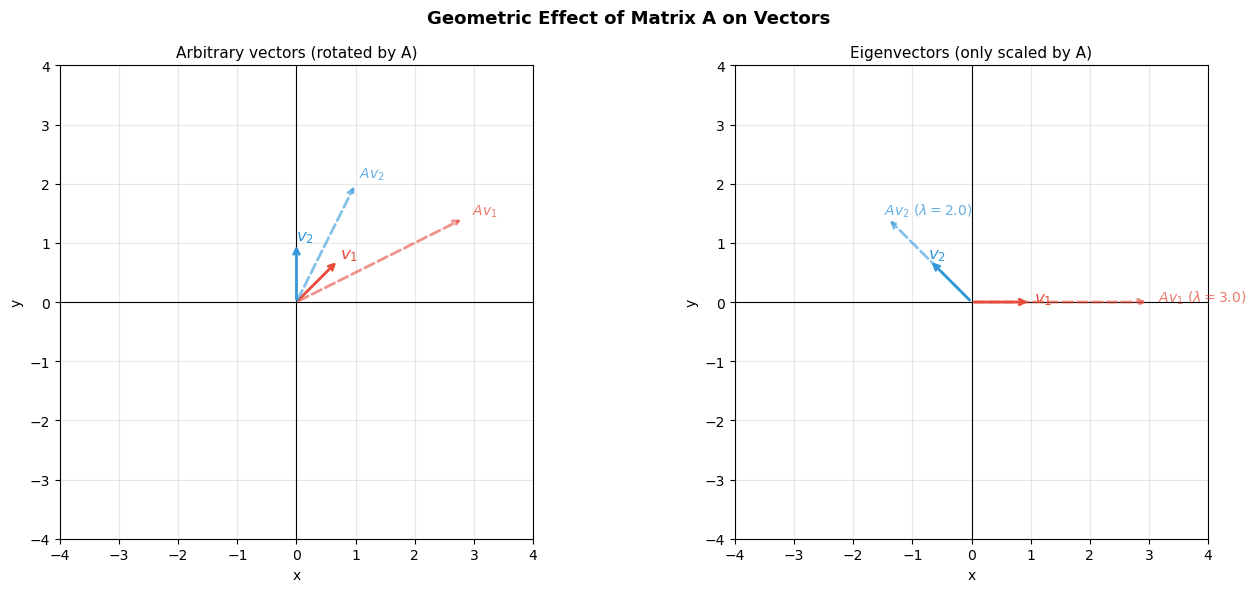


Observation: eigenvectors (right panel) point in the SAME direction before and after
transformation — they are only scaled by their eigenvalue.


In [2]:
# --- Demo: Geometric meaning of eigenvectors ---
A_demo = np.array([[3.0, 1.0],
                   [0.0, 2.0]])

eigenvalues_demo, eigenvectors_demo = np.linalg.eig(A_demo)
print('Matrix A:')
print(A_demo)
print('\nEigenvalues:', eigenvalues_demo)
print('Eigenvectors (columns):')
print(eigenvectors_demo)

# Pick two arbitrary non-eigenvectors for comparison
v_arb1 = np.array([1.0, 1.0]) / np.sqrt(2)
v_arb2 = np.array([0.0, 1.0])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors_eig = ['#e74c3c', '#3498db']

for ax, title, vecs, is_eigen in zip(
    axes,
    ['Arbitrary vectors (rotated by A)', 'Eigenvectors (only scaled by A)'],
    [(v_arb1, v_arb2), (eigenvectors_demo[:, 0], eigenvectors_demo[:, 1])],
    (False, True)
):
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.axhline(0, color='k', lw=0.8)
    ax.axvline(0, color='k', lw=0.8)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('x'); ax.set_ylabel('y')

    for i, (v, c) in enumerate(zip(vecs, colors_eig)):
        Av = A_demo @ v
        lam = eigenvalues_demo[i] if is_eigen else None
        # Original vector
        ax.annotate('', xy=v, xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color=c, lw=2))
        ax.text(v[0]*1.05, v[1]*1.05, f'$v_{i+1}$', color=c, fontsize=12, fontweight='bold')
        # Transformed vector
        ax.annotate('', xy=Av, xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color=c, lw=2, linestyle='dashed',
                                    alpha=0.6))
        label = f'$Av_{i+1}$ ($\\lambda={lam:.1f}$)' if is_eigen else f'$Av_{i+1}$'
        ax.text(Av[0]*1.05, Av[1]*1.05, label, color=c, fontsize=10, alpha=0.75)

plt.suptitle('Geometric Effect of Matrix A on Vectors', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nObservation: eigenvectors (right panel) point in the SAME direction before and after')
print('transformation — they are only scaled by their eigenvalue.')

### Exercise 1 — Verify Eigendecomposition (Basic)

Given a matrix $A$, compute its eigendecomposition $A = V \, \text{diag}(\boldsymbol{\lambda}) \, V^{-1}$ and verify the reconstruction is exact.

**Tasks:**
1. Use `np.linalg.eig` to get eigenvalues $\lambda$ and eigenvectors $V$.
2. Build the diagonal matrix $\Lambda = \text{diag}(\boldsymbol{\lambda})$.
3. Reconstruct $A$ from $V$, $\Lambda$, $V^{-1}$.
4. Check each eigenvector equation $A\mathbf{v}_i = \lambda_i \mathbf{v}_i$.

In [3]:
# Exercise 1: Verify eigendecomposition A = V diag(lambda) V^{-1}

A = np.array([[4.0, 1.0],
              [2.0, 3.0]])

# Step 1: Compute eigenvalues and eigenvectors
lambdas, V = np.linalg.eig(A)   # lambdas shape (2,), V shape (2,2), columns are eigenvectors

# Step 2: Build diagonal matrix Lambda
Lambda = np.diag(lambdas)        # shape (2,2)

# Step 3: Reconstruct A from V, Lambda, V_inv
A_rec = V @ Lambda @ np.linalg.inv(V)

# Step 4: Verify each eigenvector equation A v_i = lambda_i v_i
eigvec_checks = []
for i in range(len(lambdas)):
    Av_i = A @ V[:, i]
    lv_i = lambdas[i] * V[:, i]
    eigvec_checks.append((Av_i, lv_i))

print('Matrix A:')
print(A)
print('\nEigenvalues:', lambdas)
print('\nEigenvectors (columns of V):')
print(V)
print('\nLambda (diagonal):')
print(Lambda)
print('\nReconstructed A:')
print(A_rec)
print('\nReconstruction error:', np.max(np.abs(A - A_rec)))
for i, (Av_i, lv_i) in enumerate(eigvec_checks):
    print(f'  A*v_{i+1} = {np.round(Av_i,6)},  lambda_{i+1}*v_{i+1} = {np.round(lv_i,6)},  match: {np.allclose(Av_i, lv_i)}')

Matrix A:
[[4. 1.]
 [2. 3.]]

Eigenvalues: [5. 2.]

Eigenvectors (columns of V):
[[ 0.70710678 -0.4472136 ]
 [ 0.70710678  0.89442719]]

Lambda (diagonal):
[[5. 0.]
 [0. 2.]]

Reconstructed A:
[[4. 1.]
 [2. 3.]]

Reconstruction error: 8.881784197001252e-16
  A*v_1 = [3.535534 3.535534],  lambda_1*v_1 = [3.535534 3.535534],  match: True
  A*v_2 = [-0.894427  1.788854],  lambda_2*v_2 = [-0.894427  1.788854],  match: True


In [4]:
# Verification cell — do not modify
assert lambdas is not None, 'Compute eigenvalues'
assert V is not None, 'Compute eigenvectors'
assert Lambda is not None, 'Build Lambda'
assert A_rec is not None, 'Compute A_rec'
assert Lambda.shape == (2, 2), f'Lambda shape should be (2,2), got {Lambda.shape}'
assert np.allclose(np.diag(Lambda), np.sort(np.abs(lambdas)), atol=1e-8) or \
       set(np.round(np.diag(Lambda), 6)) == set(np.round(lambdas, 6)), \
       'Lambda diagonal should contain eigenvalues'
assert np.allclose(A, A_rec, atol=1e-8), f'Reconstruction failed. Max error: {np.max(np.abs(A - A_rec)):.2e}'
for i in range(len(lambdas)):
    Av_i = A @ V[:, i]
    lv_i = lambdas[i] * V[:, i]
    assert np.allclose(Av_i, lv_i, atol=1e-8), f'Eigenvector equation failed for i={i}'
print('Exercise 1 PASSED: A = V diag(lambda) V^-1 verified, all eigenvector equations hold.')

Exercise 1 PASSED: A = V diag(lambda) V^-1 verified, all eigenvector equations hold.


### Exercise 2 — Characteristic Polynomial for 2x2 (Basic)

Eigenvalues are roots of the **characteristic polynomial** $\det(A - \lambda I) = 0$.

For a 2x2 matrix $A = \begin{pmatrix} a & b \\ c & d \end{pmatrix}$:

$$\det(A - \lambda I) = \lambda^2 - (a+d)\lambda + (ad - bc) = 0$$

which gives:

$$\lambda = \frac{\text{tr}(A) \pm \sqrt{\text{tr}(A)^2 - 4\det(A)}}{2}$$

In [5]:
# Exercise 2: Characteristic polynomial for 2x2 matrix

A2 = np.array([[5.0, 2.0],
               [2.0, 1.0]])

a, b, c, d = A2[0, 0], A2[0, 1], A2[1, 0], A2[1, 1]

# Compute trace and determinant
trace = a + d           # tr(A)
det = a * d - b * c     # det(A)

# Compute discriminant and roots using quadratic formula
discriminant = trace**2 - 4 * det
sqrt_disc = np.sqrt(discriminant + 0j)   # +0j handles potential complex case
lambda_1 = ((trace + sqrt_disc) / 2).real   # larger root
lambda_2 = ((trace - sqrt_disc) / 2).real   # smaller root

# Ensure lambda_1 >= lambda_2
if lambda_1 < lambda_2:
    lambda_1, lambda_2 = lambda_2, lambda_1

# Compare with numpy
lambdas_np, _ = np.linalg.eig(A2)

print('Matrix A2:')
print(A2)
print(f'\nTrace = {trace:.4f},  Det = {det:.4f}')
print(f'Discriminant = {discriminant:.4f}')
print(f'\nCharacteristic polynomial roots: lambda_1 = {lambda_1:.6f},  lambda_2 = {lambda_2:.6f}')
print(f'NumPy eigenvalues:               {np.sort(lambdas_np)[::-1]}')

Matrix A2:
[[5. 2.]
 [2. 1.]]

Trace = 6.0000,  Det = 1.0000
Discriminant = 32.0000

Characteristic polynomial roots: lambda_1 = 5.828427,  lambda_2 = 0.171573
NumPy eigenvalues:               [5.82842712 0.17157288]


In [6]:
# Verification cell — do not modify
assert trace is not None, 'Compute trace'
assert det is not None, 'Compute det'
assert discriminant is not None, 'Compute discriminant'
assert lambda_1 is not None and lambda_2 is not None, 'Compute roots'
assert np.isclose(trace, a + d, atol=1e-8), 'Trace should be a+d'
assert np.isclose(det, a*d - b*c, atol=1e-8), 'Det should be ad-bc'
assert lambda_1 >= lambda_2, 'lambda_1 should be the larger root'
roots_manual = np.sort([lambda_1, lambda_2])[::-1]
roots_np = np.sort(lambdas_np.real)[::-1]
assert np.allclose(roots_manual, roots_np, atol=1e-6), \
    f'Roots do not match NumPy: manual={roots_manual}, np={roots_np}'
print('Exercise 2 PASSED: Characteristic polynomial roots match np.linalg.eig.')

Exercise 2 PASSED: Characteristic polynomial roots match np.linalg.eig.


### Exercise 3 — Power Iteration (Intermediate)

**Power iteration** finds the dominant (largest magnitude) eigenvalue and its eigenvector.

Algorithm:
1. Start with a random unit vector $\mathbf{b}_0$.
2. Iterate: $\mathbf{b}_{k+1} = \dfrac{A \mathbf{b}_k}{\|A \mathbf{b}_k\|}$
3. Estimate eigenvalue via the Rayleigh quotient: $\lambda_k = \mathbf{b}_k^T A \mathbf{b}_k$

Matrix A3:
[[4.  1.  0.5]
 [1.  3.  0.8]
 [0.5 0.8 2. ]]

Power Iteration dominant eigenvalue: 4.87329392
True dominant eigenvalue (numpy):    4.87329392
Absolute error: 1.68e-11
Converged in 18 iterations


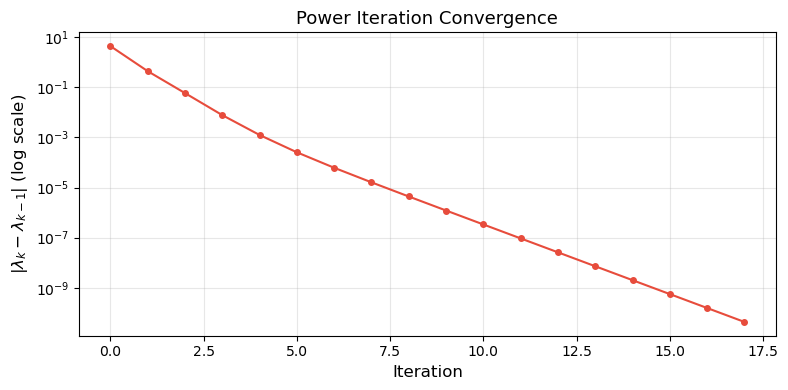

In [7]:
# Exercise 3: Power iteration

A3 = np.array([[4.0, 1.0, 0.5],
               [1.0, 3.0, 0.8],
               [0.5, 0.8, 2.0]])

def power_iteration(A, num_iterations=100, tol=1e-10):
    """
    Find dominant eigenvalue and eigenvector via power iteration.
    Returns: (eigenvalue, eigenvector, error_history)
    error_history: list of |lambda_k - lambda_{k-1}| at each step
    """
    n = A.shape[0]
    # Initialize a random unit vector
    b = np.random.randn(n)
    b = b / np.linalg.norm(b)

    lambda_prev = 0.0
    error_history = []

    for k in range(num_iterations):
        # Multiply A by current vector
        Ab = A @ b

        # Normalize to get next vector
        b = Ab / np.linalg.norm(Ab)

        # Rayleigh quotient for eigenvalue estimate
        lambda_k = b @ A @ b

        # Record error
        error = abs(lambda_k - lambda_prev)
        error_history.append(error)
        lambda_prev = lambda_k

        if error < tol and k > 0:
            break

    return lambda_k, b, error_history

eig_val, eig_vec, errors = power_iteration(A3)

# Ground truth from numpy
true_vals, true_vecs = np.linalg.eigh(A3)
true_dominant = true_vals[-1]  # largest (eigh returns ascending order)

print('Matrix A3:')
print(A3)
print(f'\nPower Iteration dominant eigenvalue: {eig_val:.8f}')
print(f'True dominant eigenvalue (numpy):    {true_dominant:.8f}')
print(f'Absolute error: {abs(eig_val - true_dominant):.2e}')
print(f'Converged in {len(errors)} iterations')

plt.figure(figsize=(8, 4))
plt.semilogy(errors, 'o-', color='#e74c3c', markersize=4, linewidth=1.5)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('$|\\lambda_k - \\lambda_{k-1}|$ (log scale)', fontsize=12)
plt.title('Power Iteration Convergence', fontsize=13)
plt.tight_layout()
plt.show()

In [8]:
# Verification cell — do not modify
assert eig_val is not None, 'power_iteration must return eigenvalue'
assert eig_vec is not None, 'power_iteration must return eigenvector'
assert len(errors) > 0, 'error_history must not be empty'
assert np.isclose(np.linalg.norm(eig_vec), 1.0, atol=1e-6), 'Eigenvector must be unit norm'
assert np.isclose(eig_val, true_dominant, atol=1e-5), \
    f'Dominant eigenvalue error too large: got {eig_val:.6f}, expected {true_dominant:.6f}'
# Verify eigenvector direction (up to sign)
Av = A3 @ eig_vec
ratio = Av / eig_vec
assert np.allclose(ratio, ratio[0], atol=1e-4), 'A*v should equal lambda*v'
print('Exercise 3 PASSED: Power iteration converges to dominant eigenvalue/eigenvector.')

Exercise 3 PASSED: Power iteration converges to dominant eigenvalue/eigenvector.


### Exercise 4 — Eigenvalues Reveal Matrix Properties (Intermediate)

Eigenvalues encode fundamental properties (Goodfellow 2.7):

| Property | Eigenvalue condition |
|---|---|
| Positive Definite (PD) | All $\lambda_i > 0$ |
| Positive Semidefinite (PSD) | All $\lambda_i \geq 0$ |
| Indefinite | Mixed signs |

Also: $\text{tr}(A) = \sum_i \lambda_i$ and $\det(A) = \prod_i \lambda_i$.

In [9]:
# Exercise 4: Eigenvalues reveal matrix properties

# 1a. Construct a 3x3 Positive Definite (PD) matrix
#     A = B @ B.T for any full-rank B guarantees PD; add scaled identity to ensure strict PD
rng4 = np.random.default_rng(0)
B_pd = rng4.standard_normal((3, 3))
A_pd = B_pd @ B_pd.T + 3 * np.eye(3)   # adding 3*I ensures all eigenvalues > 3 > 0

# 1b. Construct a 3x3 Positive Semidefinite (PSD) but NOT PD matrix
#     Use rank-deficient B (3x2): B @ B.T has rank <= 2, so at least one zero eigenvalue
B_psd = rng4.standard_normal((3, 2))
A_psd = B_psd @ B_psd.T               # rank-2 => at least one eigenvalue is exactly 0

# 1c. Construct a 3x3 Indefinite matrix (mixed eigenvalue signs)
#     Diagonal with mixed signs guarantees mixed eigenvalues
A_indef = np.diag([3.0, -1.0, 2.0])

# 2. Compute eigenvalues for each (use eigh for symmetric matrices)
eigs_pd    = np.linalg.eigh(A_pd)[0]
eigs_psd   = np.linalg.eigh(A_psd)[0]
eigs_indef = np.linalg.eigh(A_indef)[0]

# 3. Verify trace and det relationships
trace_ok_pd    = np.isclose(np.trace(A_pd),    np.sum(eigs_pd),    atol=1e-6)
det_ok_pd      = np.isclose(np.linalg.det(A_pd), np.prod(eigs_pd), atol=1e-6)
trace_ok_psd   = np.isclose(np.trace(A_psd),   np.sum(eigs_psd),   atol=1e-6)
det_ok_psd     = np.isclose(np.linalg.det(A_psd), np.prod(eigs_psd), atol=1e-6)
trace_ok_indef = np.isclose(np.trace(A_indef), np.sum(eigs_indef), atol=1e-6)
det_ok_indef   = np.isclose(np.linalg.det(A_indef), np.prod(eigs_indef), atol=1e-6)

for name, A, eigs in [('PD', A_pd, eigs_pd),
                       ('PSD', A_psd, eigs_psd),
                       ('Indefinite', A_indef, eigs_indef)]:
    print(f'\n--- {name} Matrix ---')
    print(f'  Eigenvalues: {np.round(eigs, 6)}')
    print(f'  All positive?        {np.all(eigs > 1e-10)} (PD if True)')
    print(f'  All non-negative?    {np.all(eigs >= -1e-10)} (PSD if True)')
    print(f'  Mixed signs?         {np.any(eigs > 1e-10) and np.any(eigs < -1e-10)} (Indefinite if True)')
    print(f'  Trace check:  trace={np.trace(A):.6f}, sum(eigs)={np.sum(eigs):.6f}')
    print(f'  Det check:    det={np.linalg.det(A):.6f}, prod(eigs)={np.prod(eigs):.6f}')


--- PD Matrix ---
  Eigenvalues: [3.108652 3.546392 6.309675]
  All positive?        True (PD if True)
  All non-negative?    True (PSD if True)
  Mixed signs?         False (Indefinite if True)
  Trace check:  trace=12.964719, sum(eigs)=12.964719
  Det check:    det=69.561010, prod(eigs)=69.561010

--- PSD Matrix ---
  Eigenvalues: [-0.        1.491744  7.505658]
  All positive?        False (PD if True)
  All non-negative?    True (PSD if True)
  Mixed signs?         False (Indefinite if True)
  Trace check:  trace=8.997402, sum(eigs)=8.997402
  Det check:    det=-0.000000, prod(eigs)=-0.000000

--- Indefinite Matrix ---
  Eigenvalues: [-1.  2.  3.]
  All positive?        False (PD if True)
  All non-negative?    False (PSD if True)
  Mixed signs?         True (Indefinite if True)
  Trace check:  trace=4.000000, sum(eigs)=4.000000
  Det check:    det=-6.000000, prod(eigs)=-6.000000


In [10]:
# Verification cell — do not modify
assert A_pd is not None and A_psd is not None and A_indef is not None, 'Construct all three matrices'
assert eigs_pd is not None and eigs_psd is not None and eigs_indef is not None, 'Compute all eigenvalues'
assert A_pd.shape == (3, 3), 'A_pd must be 3x3'
assert A_psd.shape == (3, 3), 'A_psd must be 3x3'
assert A_indef.shape == (3, 3), 'A_indef must be 3x3'
assert np.all(eigs_pd > 1e-10), f'A_pd eigenvalues not all positive: {eigs_pd}'
assert np.all(eigs_psd >= -1e-10), f'A_psd eigenvalues not all non-negative: {eigs_psd}'
assert not np.all(eigs_psd > 1e-10), 'A_psd should NOT be strictly PD (at least one zero eigenvalue)'
assert np.any(eigs_indef > 1e-10) and np.any(eigs_indef < -1e-10), \
    f'A_indef should have mixed-sign eigenvalues: {eigs_indef}'
for name, A, eigs in [('PD', A_pd, eigs_pd), ('PSD', A_psd, eigs_psd), ('Indefinite', A_indef, eigs_indef)]:
    assert np.isclose(np.trace(A), np.sum(eigs), atol=1e-6), f'{name}: trace != sum(eigenvalues)'
    assert np.isclose(np.linalg.det(A), np.prod(eigs), atol=1e-6), f'{name}: det != prod(eigenvalues)'
print('Exercise 4 PASSED: PD/PSD/indefinite sign patterns verified; trace and det identities hold.')

Exercise 4 PASSED: PD/PSD/indefinite sign patterns verified; trace and det identities hold.


## Part 2: Symmetric Matrices

**Goodfellow 2.7 — The Spectral Theorem:**

> Every real symmetric matrix $A = A^T$ can be decomposed as $A = Q \Lambda Q^T$ where $Q$ is orthogonal ($Q^T Q = I$) and $\Lambda$ is diagonal with real entries.

This is a much stronger result than the general eigendecomposition:
- Eigenvalues are **guaranteed real**
- Eigenvectors are **orthogonal**
- The decomposition uses $Q^T$ instead of $Q^{-1}$ (cheaper to compute)

### Demo: Symmetric vs Non-Symmetric Eigendecomposition

We compare `np.linalg.eig` on symmetric vs non-symmetric matrices to show the spectral theorem guarantees.

In [11]:
# --- Demo: Symmetric vs Non-Symmetric ---

# Non-symmetric matrix — may have complex eigenvalues
A_nonsym = np.array([[1.0, 2.0],
                     [3.0, 1.0]])

# Symmetric version: force symmetry
A_sym = np.array([[2.0, 1.5],
                  [1.5, 3.0]])

vals_ns, vecs_ns = np.linalg.eig(A_nonsym)
vals_s,  vecs_s  = np.linalg.eig(A_sym)

print('=== Non-Symmetric Matrix ===')
print('A_nonsym:\n', A_nonsym)
print('Eigenvalues (may be complex):', vals_ns)
print('Are eigenvalues real?', np.allclose(vals_ns.imag, 0))
print('Are eigenvectors orthogonal?', np.isclose(np.abs(vecs_ns[:, 0] @ vecs_ns[:, 1]), 0))

print('\n=== Symmetric Matrix ===')
print('A_sym:\n', A_sym)
print('Eigenvalues (guaranteed real):', vals_s.real)
print('Are eigenvalues real?', np.allclose(vals_s.imag, 0))
v0, v1 = vecs_s[:, 0], vecs_s[:, 1]
dot_product = v0 @ v1
print(f'Dot product of eigenvectors: {dot_product:.2e} (should be ~0 for orthogonality)')
print('Are eigenvectors orthogonal?', np.isclose(dot_product, 0, atol=1e-10))

# Verify Q Lambda Q^T = A for symmetric case
Q = vecs_s
Lam = np.diag(vals_s.real)
A_reconstructed = Q @ Lam @ Q.T
print('\nQ Lambda Q^T reconstruction error:', np.max(np.abs(A_sym - A_reconstructed)))

=== Non-Symmetric Matrix ===
A_nonsym:
 [[1. 2.]
 [3. 1.]]
Eigenvalues (may be complex): [ 3.44948974 -1.44948974]
Are eigenvalues real? True
Are eigenvectors orthogonal? False

=== Symmetric Matrix ===
A_sym:
 [[2.  1.5]
 [1.5 3. ]]
Eigenvalues (guaranteed real): [0.91886117 4.08113883]
Are eigenvalues real? True
Dot product of eigenvectors: 0.00e+00 (should be ~0 for orthogonality)
Are eigenvectors orthogonal? True

Q Lambda Q^T reconstruction error: 2.220446049250313e-16


### Exercise 5 — Spectral Theorem Verification (Intermediate)

For a random real symmetric matrix, verify the full spectral theorem:
1. $Q$ is orthogonal: $Q^T Q = I$
2. $\Lambda$ is real and diagonal
3. $A = Q \Lambda Q^T$ (reconstruction exact)
4. $A^{-1} = Q \Lambda^{-1} Q^T$ (if $A$ invertible)

In [12]:
# Exercise 5: Spectral theorem verification

# Generate a random 4x4 symmetric positive definite matrix
rng = np.random.default_rng(7)
B = rng.standard_normal((4, 4))
A5 = B @ B.T + 2 * np.eye(4)   # guaranteed PD

# 1. Decompose using np.linalg.eigh
#    eigh returns (eigenvalues_ascending, eigenvectors) for symmetric matrices
eigenvalues5, Q5 = np.linalg.eigh(A5)   # eigenvalues5 shape (4,), Q5 shape (4,4)

# 2. Verify Q is orthogonal: Q^T Q should be identity
QtQ = Q5.T @ Q5

# 3. Build Lambda and reconstruct A
Lambda5 = np.diag(eigenvalues5)           # diag matrix from eigenvalues5
A5_rec  = Q5 @ Lambda5 @ Q5.T            # Q Lambda Q^T

# 4. Compute A^{-1} using the spectral decomposition
#    A^{-1} = Q Lambda^{-1} Q^T
Lambda5_inv     = np.diag(1.0 / eigenvalues5)   # diag matrix with 1/lambda_i on diagonal
A5_inv_spectral = Q5 @ Lambda5_inv @ Q5.T       # spectral inverse
A5_inv_direct   = np.linalg.inv(A5)             # ground truth

print('Original A5:')
print(np.round(A5, 4))
print('\nEigenvalues (ascending):', np.round(eigenvalues5, 6))
print('\nQ^T Q (should be I):')
print(np.round(QtQ, 8))
print('\nReconstruction error ||A - Q Lambda Q^T||_F:', 
      np.linalg.norm(A5 - A5_rec, 'fro'))
print('\nSpectral inverse vs direct inverse max error:', 
      np.max(np.abs(A5_inv_spectral - A5_inv_direct)))

Original A5:
[[ 2.9576 -1.5069 -0.6381 -0.8891]
 [-1.5069  4.9899  1.3468  1.8049]
 [-0.6381  1.3468  2.9946  0.7593]
 [-0.8891  1.8049  0.7593  3.3612]]

Eigenvalues (ascending): [2.102993 2.250556 2.40983  7.539815]

Q^T Q (should be I):
[[ 1. -0. -0.  0.]
 [-0.  1.  0. -0.]
 [-0.  0.  1. -0.]
 [ 0. -0. -0.  1.]]

Reconstruction error ||A - Q Lambda Q^T||_F: 4.8022760776605205e-15

Spectral inverse vs direct inverse max error: 2.7755575615628914e-16


In [13]:
# Verification cell — do not modify
assert eigenvalues5 is not None, 'Compute eigenvalues5'
assert Q5 is not None, 'Compute Q5'
assert QtQ is not None, 'Compute QtQ'
assert Lambda5 is not None, 'Build Lambda5'
assert A5_rec is not None, 'Compute A5_rec'
assert Lambda5_inv is not None, 'Build Lambda5_inv'
assert A5_inv_spectral is not None, 'Compute A5_inv_spectral'
assert np.all(eigenvalues5 == np.sort(eigenvalues5)), 'eigh should return ascending eigenvalues'
assert np.allclose(eigenvalues5.imag if np.iscomplexobj(eigenvalues5) else np.zeros(4), 0), \
    'Eigenvalues must be real'
assert np.allclose(QtQ, np.eye(4), atol=1e-10), \
    f'Q^T Q not identity: max dev {np.max(np.abs(QtQ - np.eye(4))):.2e}'
assert np.allclose(A5, A5_rec, atol=1e-10), 'Reconstruction A = Q Lambda Q^T failed'
assert np.allclose(A5_inv_spectral, A5_inv_direct, atol=1e-10), 'Spectral inverse != direct inverse'
print('Exercise 5 PASSED: Spectral theorem fully verified (orthogonality, reconstruction, inverse).')

Exercise 5 PASSED: Spectral theorem fully verified (orthogonality, reconstruction, inverse).


### Exercise 6 — Quadratic Form Visualization (Intermediate)

A **quadratic form** is $f(\mathbf{x}) = \mathbf{x}^T A \mathbf{x}$. The level set $\{\mathbf{x} : \mathbf{x}^T A \mathbf{x} = 1\}$ reveals the geometry:

- **PD matrix** → ellipse (all axes point inward)
- **Indefinite matrix** → hyperbola (some axes point outward)

The eigenvectors of $A$ give the **principal axes** of these curves.

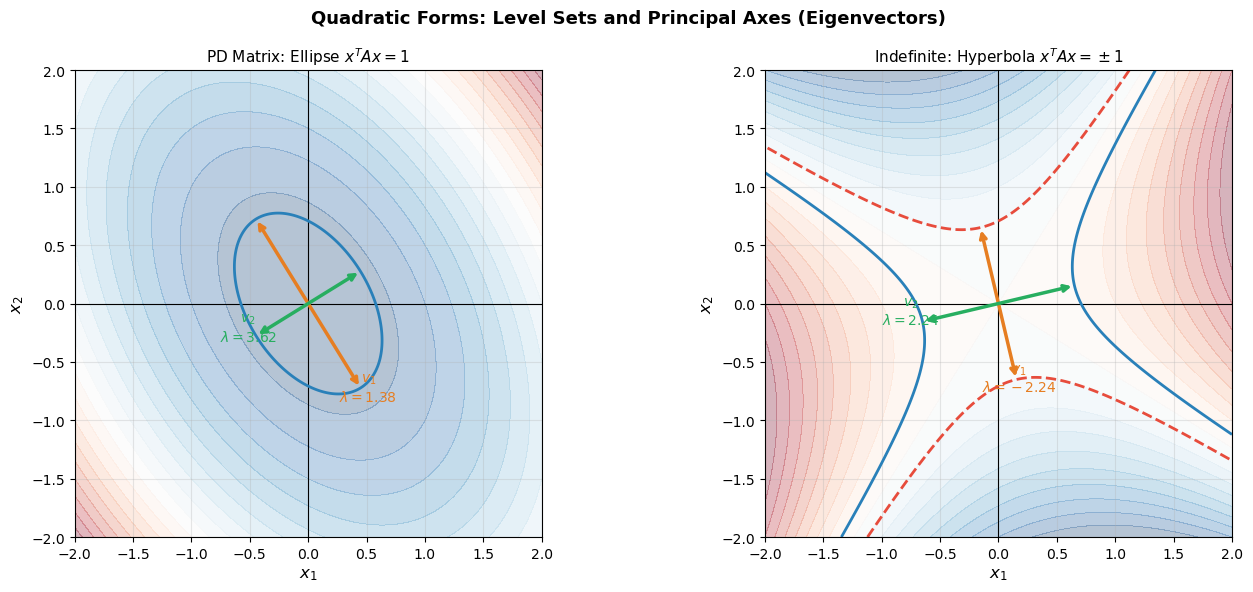

In [14]:
# Exercise 6: Quadratic form visualization

A_pd6  = np.array([[3.0, 1.0],
                   [1.0, 2.0]])   # Positive Definite

A_indef6 = np.array([[ 2.0, 1.0],
                     [ 1.0, -2.0]])   # Indefinite

# Create grid for contour plotting
x_range = np.linspace(-2.0, 2.0, 400)
y_range = np.linspace(-2.0, 2.0, 400)
X, Y = np.meshgrid(x_range, y_range)

# 1. Compute quadratic form Z = x^T A x on the grid for both matrices
#    Vectorized: Z = A[0,0]*X^2 + (A[0,1]+A[1,0])*X*Y + A[1,1]*Y^2
Z_pd    = A_pd6[0,0]*X**2    + (A_pd6[0,1]    + A_pd6[1,0])    * X * Y + A_pd6[1,1]*Y**2
Z_indef = A_indef6[0,0]*X**2 + (A_indef6[0,1] + A_indef6[1,0]) * X * Y + A_indef6[1,1]*Y**2

# 2. Get eigenvalues and eigenvectors for both matrices
eigs_pd6,    vecs_pd6    = np.linalg.eigh(A_pd6)
eigs_indef6, vecs_indef6 = np.linalg.eigh(A_indef6)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, Z, A_mat, eigs, vecs, title in [
    (axes[0], Z_pd,    A_pd6,    eigs_pd6,    vecs_pd6,    'PD Matrix: Ellipse $x^T A x = 1$'),
    (axes[1], Z_indef, A_indef6, eigs_indef6, vecs_indef6, 'Indefinite: Hyperbola $x^T A x = \\pm 1$')
]:
    ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
    ax.set_aspect('equal')
    ax.axhline(0, color='k', lw=0.8); ax.axvline(0, color='k', lw=0.8)
    ax.set_xlabel('$x_1$', fontsize=12); ax.set_ylabel('$x_2$', fontsize=12)
    ax.set_title(title, fontsize=11)

    ax.contour(X, Y, Z, levels=[1.0], colors='#2980b9', linewidths=2)
    ax.contour(X, Y, Z, levels=[-1.0], colors='#e74c3c', linewidths=2, linestyles='--')
    ax.contourf(X, Y, Z, levels=20, cmap='RdBu_r', alpha=0.3)

    # Overlay eigenvectors scaled by 1/sqrt(|lambda|)
    colors_ev = ['#e67e22', '#27ae60']
    for i in range(2):
        if abs(eigs[i]) > 1e-10:
            scale = 1.0 / np.sqrt(abs(eigs[i]))
            ev = vecs[:, i] * scale
            ax.annotate('', xy=ev, xytext=-ev,
                        arrowprops=dict(arrowstyle='<->', color=colors_ev[i], lw=2.5))
            ax.text(ev[0]*1.15, ev[1]*1.15,
                    f'$v_{i+1}$\n$\\lambda={eigs[i]:.2f}$',
                    color=colors_ev[i], fontsize=10, ha='center')

plt.suptitle('Quadratic Forms: Level Sets and Principal Axes (Eigenvectors)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
# Verification cell — do not modify
assert Z_pd is not None, 'Compute Z_pd'
assert Z_indef is not None, 'Compute Z_indef'
assert eigs_pd6 is not None and vecs_pd6 is not None
assert eigs_indef6 is not None and vecs_indef6 is not None
assert Z_pd.shape == X.shape, 'Z_pd must match grid shape'
assert Z_indef.shape == X.shape, 'Z_indef must match grid shape'
# Spot check a few grid points for Z_pd
for xi, yi in [(1.0, 0.0), (0.0, 1.0), (0.5, 0.5)]:
    expected = np.array([xi, yi]) @ A_pd6 @ np.array([xi, yi])
    idx_x = np.argmin(np.abs(x_range - xi))
    idx_y = np.argmin(np.abs(y_range - yi))
    assert np.isclose(Z_pd[idx_y, idx_x], expected, atol=0.05), \
        f'Z_pd at ({xi},{yi}) = {Z_pd[idx_y, idx_x]:.4f}, expected {expected:.4f}'
assert np.all(eigs_pd6 > 0), 'A_pd6 should have all positive eigenvalues'
assert np.any(eigs_indef6 > 0) and np.any(eigs_indef6 < 0), 'A_indef6 should have mixed signs'
print('Exercise 6 PASSED: Quadratic forms computed correctly for PD and indefinite matrices.')

Exercise 6 PASSED: Quadratic forms computed correctly for PD and indefinite matrices.


### Exercise 7 — Inverse Power Iteration with Shift (Challenging)

**Motivation:** Power iteration finds the *largest* eigenvalue. To find the eigenvalue *closest to a target $\sigma$*, use the **shift-invert** strategy:

$$(A - \sigma I)^{-1} \mathbf{b}_k \to \text{eigenvector of } A \text{ closest to } \sigma$$

The eigenvalue of $(A - \sigma I)^{-1}$ is $\mu = \frac{1}{\lambda - \sigma}$, so the largest $\mu$ corresponds to the $\lambda$ closest to $\sigma$.

Matrix A7:
[[5.  1.  0.5]
 [1.  3.  0.8]
 [0.5 0.8 1.5]]

Inverse power iteration (sigma=0): lambda_min = 1.1522699637
True smallest eigenvalue (numpy):  1.1522699637
Absolute error: 2.02e-13
Converged in 17 iterations

Closest eigenvalue to sigma=3.5: 2.78462502
All eigenvalues: [1.15226996 2.78462502 5.56310502]


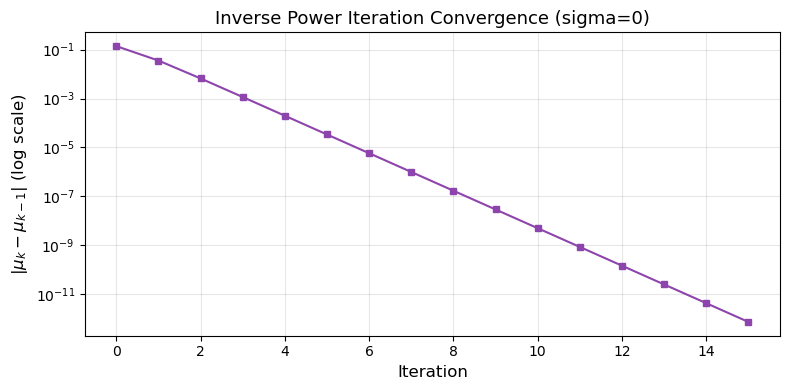

In [16]:
# Exercise 7: Inverse power iteration with shift

A7 = np.array([[5.0, 1.0, 0.5],
               [1.0, 3.0, 0.8],
               [0.5, 0.8, 1.5]])

def inverse_power_iteration(A, sigma=0.0, num_iterations=200, tol=1e-12):
    """
    Find eigenvalue of A closest to sigma using shift-invert power iteration.
    Algorithm:
      1. Form M = A - sigma * I
      2. Factorize M (or compute its inverse)
      3. Apply power iteration to M^{-1}
      4. Recover eigenvalue of A: lambda = 1/mu + sigma
         where mu is eigenvalue of M^{-1}
    Returns: (eigenvalue, eigenvector, error_history)
    """
    n = A.shape[0]
    # Step 1: Form the shifted matrix M = A - sigma * I
    M = A - sigma * np.eye(n)

    # Step 2: Precompute inverse of M
    M_inv = np.linalg.inv(M)

    # Step 3: Power iteration on M_inv
    b = np.random.default_rng(99).standard_normal(n)
    b = b / np.linalg.norm(b)

    mu_prev = 0.0
    error_history = []

    for k in range(num_iterations):
        # Apply M_inv
        Mb = M_inv @ b

        # Normalize
        b = Mb / np.linalg.norm(Mb)

        # Rayleigh quotient for M_inv eigenvalue
        mu_k = b @ M_inv @ b

        error = abs(mu_k - mu_prev)
        error_history.append(error)
        mu_prev = mu_k

        if error < tol and k > 0:
            break

    # Step 4: Recover original eigenvalue: lambda = 1/mu + sigma
    lambda_k = 1.0 / mu_k + sigma

    return lambda_k, b, error_history

# Find smallest eigenvalue (sigma = 0)
lambda_min_inv, vec_min, errors7 = inverse_power_iteration(A7, sigma=0.0)

# Ground truth
true_vals7, _ = np.linalg.eigh(A7)
true_min = true_vals7[0]

print('Matrix A7:')
print(A7)
print(f'\nInverse power iteration (sigma=0): lambda_min = {lambda_min_inv:.10f}')
print(f'True smallest eigenvalue (numpy):  {true_min:.10f}')
print(f'Absolute error: {abs(lambda_min_inv - true_min):.2e}')
print(f'Converged in {len(errors7)} iterations')

# Find eigenvalue closest to sigma=3.5
lambda_shift, _, _ = inverse_power_iteration(A7, sigma=3.5)
print(f'\nClosest eigenvalue to sigma=3.5: {lambda_shift:.8f}')
print(f'All eigenvalues: {np.round(true_vals7, 8)}')

plt.figure(figsize=(8, 4))
plt.semilogy(errors7[1:], 's-', color='#8e44ad', markersize=4, linewidth=1.5)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('$|\\mu_k - \\mu_{k-1}|$ (log scale)', fontsize=12)
plt.title('Inverse Power Iteration Convergence (sigma=0)', fontsize=13)
plt.tight_layout()
plt.show()

In [17]:
# Verification cell — do not modify
assert lambda_min_inv is not None, 'inverse_power_iteration must return eigenvalue'
assert vec_min is not None, 'inverse_power_iteration must return eigenvector'
assert np.isclose(np.linalg.norm(vec_min), 1.0, atol=1e-6), 'Eigenvector must be unit norm'
assert np.isclose(lambda_min_inv, true_min, atol=1e-6), \
    f'Smallest eigenvalue error too large: got {lambda_min_inv:.8f}, expected {true_min:.8f}'
# Verify eigenvector satisfies A v = lambda v
Av7 = A7 @ vec_min
lv7 = lambda_min_inv * vec_min
assert np.allclose(np.abs(Av7), np.abs(lv7), atol=1e-5), 'A*v should equal lambda*v'
# Verify shift target
assert np.isclose(lambda_shift, true_vals7[np.argmin(np.abs(true_vals7 - 3.5))], atol=1e-4), \
    'Shift to sigma=3.5 did not find closest eigenvalue'
print('Exercise 7 PASSED: Inverse power iteration with shift finds eigenvalue closest to sigma.')

Exercise 7 PASSED: Inverse power iteration with shift finds eigenvalue closest to sigma.


### Exercise 8 — Basic QR Algorithm (Challenging)

The **QR algorithm** is the standard method for computing *all* eigenvalues of a matrix. It iterates:

$$A_0 = A, \quad A_{k+1} = R_k Q_k \quad \text{where } A_k = Q_k R_k$$

- $Q_k$ is orthogonal, $R_k$ is upper triangular (QR factorization)
- $A_{k+1} = R_k Q_k = Q_k^T A_k Q_k$ is a **similarity transform** (preserves eigenvalues)
- As $k \to \infty$, $A_k$ converges to a triangular (or diagonal for symmetric) matrix
- The **diagonal entries** of $A_k$ converge to the eigenvalues

Matrix A8:
[[4.  1.  0.5 0.2]
 [1.  3.  0.8 0.1]
 [0.5 0.8 2.  0.4]
 [0.2 0.1 0.4 1.5]]

True eigenvalues (numpy, descending):  [4.90507556 2.58244207 1.80931023 1.20317214]
QR algorithm diagonal (descending):    [4.90507556 2.58244207 1.80931023 1.20317214]
Max error: 7.11e-15

Final A_k (should be near triangular):
[[ 4.905076 -0.       -0.       -0.      ]
 [ 0.        2.582442  0.       -0.      ]
 [ 0.        0.        1.80931  -0.      ]
 [ 0.       -0.        0.        1.203172]]


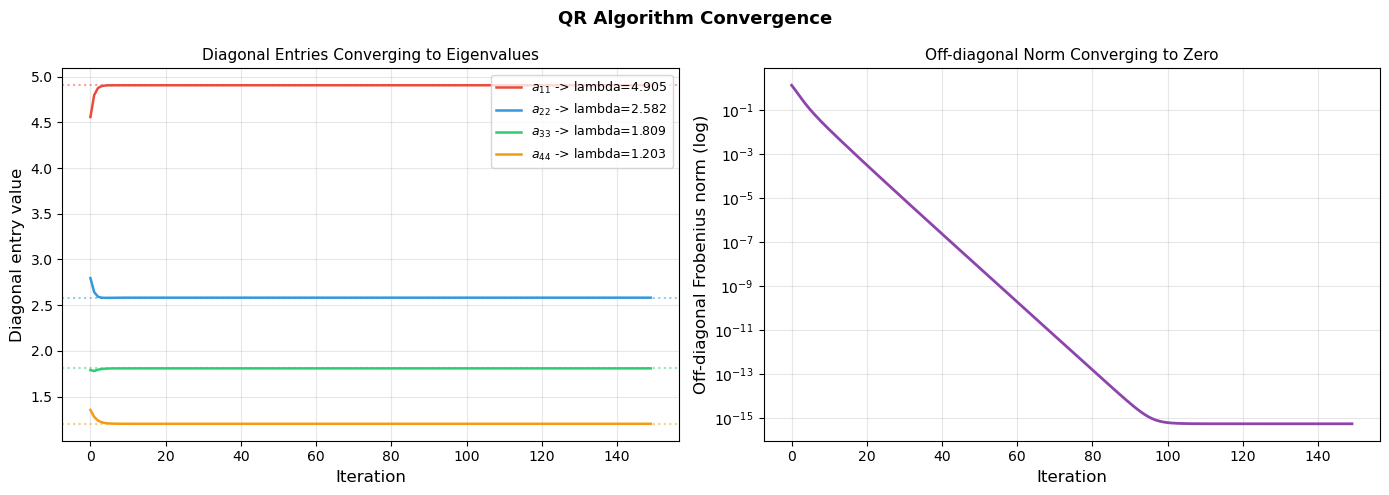

In [18]:
# Exercise 8: Basic QR algorithm

A8 = np.array([[ 4.0,  1.0,  0.5,  0.2],
               [ 1.0,  3.0,  0.8,  0.1],
               [ 0.5,  0.8,  2.0,  0.4],
               [ 0.2,  0.1,  0.4,  1.5]])

def qr_algorithm(A, num_iterations=100):
    """
    Basic QR iteration: A_{k+1} = R_k Q_k where A_k = Q_k R_k.
    Returns:
      - diagonal_history: list of np.diag(A_k) at each iteration
      - offdiag_norms:    list of off-diagonal Frobenius norms at each iteration
      - A_final:          converged matrix
    """
    A_k = A.copy().astype(float)
    diagonal_history = []
    offdiag_norms = []

    for k in range(num_iterations):
        # Step 1: QR factorization of A_k
        Q_k, R_k = np.linalg.qr(A_k)

        # Step 2: Similarity update A_{k+1} = R_k Q_k
        A_k = R_k @ Q_k

        # Record diagonal (eigenvalue estimates) and off-diagonal norm
        diagonal_history.append(np.diag(A_k).copy())
        # Off-diagonal Frobenius norm
        off_diag_norm = np.linalg.norm(A_k - np.diag(np.diag(A_k)), 'fro')
        offdiag_norms.append(off_diag_norm)

    return diagonal_history, offdiag_norms, A_k

diag_history, offdiag_norms, A8_final = qr_algorithm(A8, num_iterations=150)

true_eigs8 = np.sort(np.linalg.eigh(A8)[0])[::-1]
final_diag = np.sort(diag_history[-1])[::-1]

print('Matrix A8:')
print(A8)
print(f'\nTrue eigenvalues (numpy, descending):  {np.round(true_eigs8, 8)}')
print(f'QR algorithm diagonal (descending):    {np.round(final_diag, 8)}')
print(f'Max error: {np.max(np.abs(final_diag - true_eigs8)):.2e}')
print(f'\nFinal A_k (should be near triangular):')
print(np.round(A8_final, 6))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: diagonal elements converging
diag_arr = np.array(diag_history)
colors8 = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
for i in range(4):
    axes[0].plot(diag_arr[:, i], color=colors8[i],
                 label=f'$a_{{{i+1}{i+1}}}$ -> lambda={true_eigs8[i]:.3f}',
                 linewidth=1.8)
    axes[0].axhline(true_eigs8[i], color=colors8[i], linestyle=':', alpha=0.5)
axes[0].set_xlabel('Iteration', fontsize=12)
axes[0].set_ylabel('Diagonal entry value', fontsize=12)
axes[0].set_title('Diagonal Entries Converging to Eigenvalues', fontsize=11)
axes[0].legend(fontsize=9)

# Right: off-diagonal norm
axes[1].semilogy(offdiag_norms, color='#8e44ad', linewidth=2)
axes[1].set_xlabel('Iteration', fontsize=12)
axes[1].set_ylabel('Off-diagonal Frobenius norm (log)', fontsize=12)
axes[1].set_title('Off-diagonal Norm Converging to Zero', fontsize=11)

plt.suptitle('QR Algorithm Convergence', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
# Verification cell — do not modify
assert len(diag_history) > 0, 'qr_algorithm must return diagonal_history'
assert len(offdiag_norms) > 0, 'qr_algorithm must return offdiag_norms'
assert A8_final is not None, 'qr_algorithm must return A_final'
# Check similarity: A_final must have same eigenvalues as A8
assert np.allclose(np.sort(np.linalg.eig(A8_final)[0].real),
                   np.sort(np.linalg.eig(A8)[0].real), atol=1e-6), \
    'QR similarity transform should preserve eigenvalues'
# Check convergence: off-diagonal norm should decrease
assert offdiag_norms[-1] < offdiag_norms[0], 'Off-diagonal norm should decrease'
assert offdiag_norms[-1] < 1e-6, f'QR did not converge: final off-diag norm = {offdiag_norms[-1]:.2e}'
# Diagonal should converge to eigenvalues
assert np.allclose(np.sort(diag_history[-1])[::-1], true_eigs8, atol=1e-5), \
    f'Diagonal did not converge to eigenvalues. Got {np.sort(diag_history[-1])[::-1]}, expected {true_eigs8}'
print('Exercise 8 PASSED: QR algorithm converges — diagonal entries match eigenvalues, off-diagonal norm -> 0.')

Exercise 8 PASSED: QR algorithm converges — diagonal entries match eigenvalues, off-diagonal norm -> 0.


## Summary

This lab covered **Section 2.7 (Eigendecomposition)** of Goodfellow et al.:

### Key Concepts

| Concept | Formula | Key Takeaway |
|---|---|---|
| Eigenvalue equation | $A\mathbf{v} = \lambda\mathbf{v}$ | Eigenvectors only scale, never rotate |
| Eigendecomposition | $A = V\Lambda V^{-1}$ | Requires $n$ linearly independent eigenvectors |
| Characteristic polynomial | $\det(A - \lambda I) = 0$ | Roots are eigenvalues |
| Spectral theorem | $A = Q\Lambda Q^T$ | Real symmetric matrices always diagonalize with orthogonal $Q$ |
| Trace identity | $\text{tr}(A) = \sum_i \lambda_i$ | Eigenvalues sum to trace |
| Determinant identity | $\det(A) = \prod_i \lambda_i$ | Eigenvalues multiply to determinant |
| Definiteness | Sign of eigenvalues | PD: all $>0$; PSD: all $\geq 0$; Indefinite: mixed |
| Quadratic forms | $\mathbf{x}^T A \mathbf{x}$ | Level sets are ellipses (PD) or hyperbolas (indefinite) |

### Algorithms Implemented

| Algorithm | Purpose | Convergence |
|---|---|---|
| Power iteration | Dominant eigenvalue | Linear, rate $|\lambda_2/\lambda_1|$ |
| Inverse power iteration | Eigenvalue closest to $\sigma$ | Linear, rate $|\mu_2/\mu_1|$ of shifted inverse |
| QR algorithm | All eigenvalues simultaneously | Quadratic (with shifts) |